In [ ]:
!nvidia-smi

Tue Sep 16 08:24:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Install YOLOv10

**NOTE:** Currently, YOLOv10 does not have its own PyPI package. Therefore, we need to install the code from the source.

In [ ]:
!git clone https://github.com/ddilbazTT/yolov10.git
%cd yolov10

#source updated, this includes weights_only = False fix

Cloning into 'yolov10'...
remote: Enumerating objects: 20342, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 20342 (delta 3), reused 0 (delta 0), pack-reused 20335 (from 2)
Receiving objects: 100% (20342/20342), 11.11 MiB | 16.07 MiB/s, done.
Resolving deltas: 100% (14355/14355), done.
/content/yolov10


In [ ]:
!pip install -r requirements.txt -q

ERROR: Could not find a version that satisfies the requirement torch==2.0.1 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0)
ERROR: No matching distribution found for torch==2.0.1


In [ ]:
!pip install -q supervision roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 119.7 MB/s eta 0:00:00


In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.0 MB/s eta 0:00:00


## Download pre-trained weights

**NOTE:** YOLOv10 provides weight files pre-trained on the COCO dataset in various sizes. Let's download them.

In [ ]:
!mkdir -p {HOME}/weights
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10n.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10s.pt
!ls -lh {HOME}/weights

total 43M
-rw-r--r-- 1 root root 11M May 26  2024 yolov10n.pt
-rw-r--r-- 1 root root 32M May 26  2024 yolov10s.pt


## Inference with Pre-trained COCO Model

**NOTE:** YOLOv10 is based on YOLOv8, and like YOLOv8, it can be used in both CLI and SDK modes.

### 💻 CLI

In [ ]:
%cd {HOME}

!yolo task=detect mode=predict save=True \
model={HOME}/weights/yolov10s.pt \
source={HOME}/test_yolo.png

#inference with pretrained weights; same test image

/content
Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv10s summary (fused): 106 layers, 7,248,960 parameters, 43,440 gradients, 21.6 GFLOPs

image 1/1 /content/test_yolo.png: 384x640 3 persons, 9 cars, 96.2ms
Speed: 29.7ms preprocess, 96.2ms inference, 69.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


/content


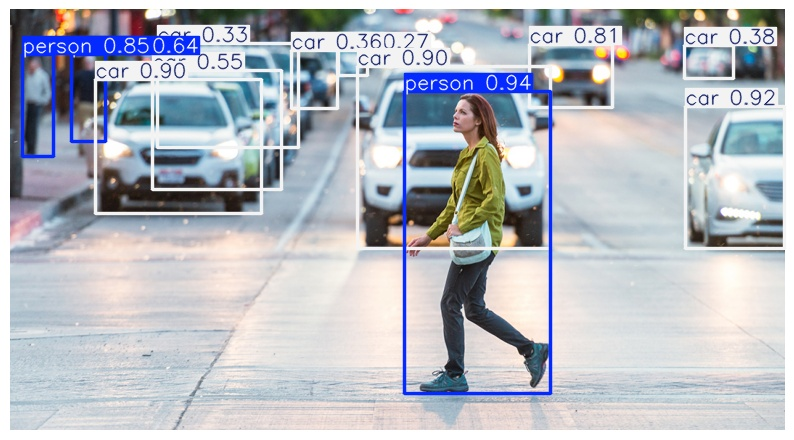

In [ ]:
%cd {HOME}

from IPython.display import Image

Image(filename='/content/runs/detect/predict/test_yolo.jpg', height=600)

## Download dataset from Roboflow Universe

In [ ]:
#fine tuning on this dataset

!mkdir {HOME}/datasets
%cd {HOME}/datasets

from roboflow import Roboflow
rf = Roboflow(api_key="PREtYuS13VXPKlpKYGKD")
project = rf.workspace("capstone-cra8x").project("citypersons-woqjq-ike0o-dtqfy")
version = project.version(1)
dataset = version.download("yolov8") #using yolov8 as no official version of yolov10 exists, and this yolov10 is based on yolov8 architecture


/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Citypersons-1 in yolov8:: 100%|██████████| 6962/6962 [00:03<00:00, 2214.58it/s]


In [ ]:
import os

def count_files_in_directory(directory_path):
    """
    Counts the number of files directly within a specified directory.
    Subdirectories and their contents are not included in the count.

    Args:
        directory_path (str): The path to the directory.

    Returns:
        int: The number of files found in the directory.
    """
    count = 0
    try:
        for entry in os.listdir(directory_path):
            full_path = os.path.join(directory_path, entry)
            if os.path.isfile(full_path):
                count += 1
        return count
    except FileNotFoundError:
        print(f"Error: Directory not found at '{directory_path}'")
        return -1
    except Exception as e:
        print(f"An error occurred: {e}")
        return -1

# Example usage:
folder_to_check = "/content/datasets/Citypersons-1/test/images"  # Replace with the actual path to your folder
number_of_files = count_files_in_directory(folder_to_check)

if number_of_files != -1:
    print(f"Number of files in '{folder_to_check}': {number_of_files}")

Number of files in '/content/datasets/Citypersons-1/test/images': 341


In [ ]:
import os

def count_files_in_directory(directory_path):
    """
    Counts the number of files directly within a specified directory.
    Subdirectories and their contents are not included in the count.

    Args:
        directory_path (str): The path to the directory.

    Returns:
        int: The number of files found in the directory.
    """
    count = 0
    try:
        for entry in os.listdir(directory_path):
            full_path = os.path.join(directory_path, entry)
            if os.path.isfile(full_path):
                count += 1
        return count
    except FileNotFoundError:
        print(f"Error: Directory not found at '{directory_path}'")
        return -1
    except Exception as e:
        print(f"An error occurred: {e}")
        return -1

# Example usage:
folder_to_check = "/content/datasets/Citypersons-1/train/images"  # Replace with the actual path to your folder
number_of_files = count_files_in_directory(folder_to_check)

if number_of_files != -1:
    print(f"Number of files in '{folder_to_check}': {number_of_files}")

Number of files in '/content/datasets/Citypersons-1/train/images': 2792


In [ ]:
import os

def count_files_in_directory(directory_path):
    """
    Counts the number of files directly within a specified directory.
    Subdirectories and their contents are not included in the count.

    Args:
        directory_path (str): The path to the directory.

    Returns:
        int: The number of files found in the directory.
    """
    count = 0
    try:
        for entry in os.listdir(directory_path):
            full_path = os.path.join(directory_path, entry)
            if os.path.isfile(full_path):
                count += 1
        return count
    except FileNotFoundError:
        print(f"Error: Directory not found at '{directory_path}'")
        return -1
    except Exception as e:
        print(f"An error occurred: {e}")
        return -1

# Example usage:
folder_to_check = "/content/datasets/Citypersons-1/valid/images"  # Replace with the actual path to your folder
number_of_files = count_files_in_directory(folder_to_check)

if number_of_files != -1:
    print(f"Number of files in '{folder_to_check}': {number_of_files}")

Number of files in '/content/datasets/Citypersons-1/valid/images': 342


## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train epochs=100 batch=16 plots=True patience=10 \
model={HOME}/weights/yolov10s.pt \
data={dataset.location}/data.yaml

/content
Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/Citypersons-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/weights/yolov10s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    labels_correlogram.jpg  weights
events.out.tfevents.1718449794.9f509d2255e2.1686.0  labels.jpg


In [ ]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv10s summary (fused): 106 layers, 7,219,161 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3448.5±975.3 MB/s, size: 156.1 KB)
val: Scanning /content/datasets/Citypersons-1/valid/labels.cache... 342 images, 13 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 342/342 6.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 3.5it/s 6.4s
                   all        342       3414      0.551      0.243      0.252      0.154
                  None        281       1202      0.315      0.049     0.0529     0.0169
                ignore         42         49       0.77     0.0204      0.031     0.0195
                   ped        289       2163      0.568      0.661      0.671      0.425
Speed: 0.7ms preprocess, 7.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/dete

In [ ]:
%cd {HOME}

!yolo task=detect mode=predict save=True \
model={HOME}/runs/detect/train/weights/best.pt \
source={HOME}/test_yolo.png

/content
Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv10s summary (fused): 106 layers, 7,219,161 parameters, 0 gradients, 21.4 GFLOPs

image 1/1 /content/test_yolo.png: 384x640 1 ped, 58.6ms
Speed: 8.6ms preprocess, 58.6ms inference, 25.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


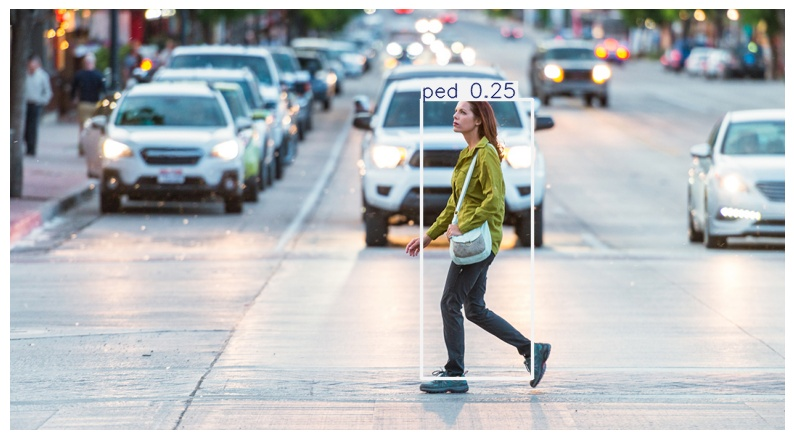

In [ ]:
Image(filename='/content/runs/detect/predict2/test_yolo.jpg', height=600)

In [ ]:
%cd /content/drive/MyDrive/MLPR_new_runs/yolov10
%cp -av /content/runs/ /content/drive/MyDrive/MLPR_new_runs/yolov10

/content/drive/MyDrive/MLPR_new_runs/yolov10
'/content/runs/' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs'
'/content/runs/detect' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect'
'/content/runs/detect/predict' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect/predict'
'/content/runs/detect/predict/test_yolo.jpg' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect/predict/test_yolo.jpg'
'/content/runs/detect/train' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect/train'
'/content/runs/detect/train/weights' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect/train/weights'
'/content/runs/detect/train/weights/last.pt' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect/train/weights/last.pt'
'/content/runs/detect/train/weights/best.pt' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect/train/weights/best.pt'
'/content/runs/detect/train/args.yaml' -> '/content/drive/MyDrive/MLPR_new_runs/yolov10/runs/detect/